# Potato Disease Project

## Data Exploration

In [32]:
from glob import glob

file_paths = {
    "Healthy" : glob("./data/PlantVillage/Potato___healthy/*"),
    "Early-Blight" : glob("./data/PlantVillage/Potato___Early_blight/*"),
    "Late-Blight" : glob("./data/PlantVillage/Potato___Late_blight/*")
}

CLASS_TO_ID = {
    "Healthy": 0,
    "Early-Blight": 1,
    "Late-Blight": 2
}

ID_TO_CLASS = {
    0: "Healthy",
    1: "Early Blight Potato",
    2: "Late Blight Potato"
}


In [3]:
FILES_PATH = file_paths["Healthy"]
# Checking if all file have the same format
for file_path in FILES_PATH:
    file_extension = (file_path.split("."))[-1]

    if file_extension.lower() != "jpg":
        print(file_extension)

In [4]:
print(f"Number of Healthy Potatoes: {len(file_paths["Healthy"])}")
print(f"Number of Potatoes with Early Blight: {len(file_paths["Early-Blight"])}")
print(f"Number of Potatoes with Late Blight: {len(file_paths["Late-Blight"])}")

Number of Healthy Potatoes: 152
Number of Potatoes with Early Blight: 1000
Number of Potatoes with Late Blight: 1000


As we can see, there is clear class imbalance. We must also try checking the diversity of the data.

Let us start by viewing some of the images.

In [5]:
from IPython.display import HTML, display
import random

# Replace with your actual file paths
IMAGE_PATHS = list()

for paths in file_paths.values():
    IMAGE_PATHS += paths

random.shuffle(IMAGE_PATHS)
NUMBER_OF_IMAGES = 45

# Build HTML string with images side-by-side
html_content = "".join(
    f'<div style="display:inline-block; margin:10px;">'
    f'<img src="{path}" width="200"/>'
    f'</div>'
    for path in IMAGE_PATHS[:NUMBER_OF_IMAGES]
)

display(HTML(html_content))


I can see that most of the leaves are held upright. Moreover, there is clear class imbalance.

Maybe it will be good to apply some image augmentation on the training dataset...

In [58]:
import cv2

def augment_data(files, target_size):

    num_loops = int(target_size // len(files)) + 1
    augmented_data = list()
    label_id = files[0][-1]
    
    for _ in range(num_loops):
        for tup in files:
            if len(augmented_data) >= target_size:
                break
            img = tup[0]
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            center = (img_rgb.shape[1] // 2, img_rgb.shape[0] // 2)
            angle = random.randint(-359,360)
            scale = random.randint(7,14) / 10.0

            rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
            rotated_image = cv2.warpAffine(img_rgb, rotation_matrix, (img.shape[1], img.shape[0]))

            augmented_data.append((rotated_image, label_id))
        if len(augmented_data) >= target_size:
            break

    return augmented_data

In [62]:
import cv2
import matplotlib.pyplot as plt
import random

max_file_count = 0
SPLIT_RATIO = 0.8

# Get maximum number of files
for values in file_paths.values():
    if len(values) > max_file_count:
        max_file_count = len(values)

target_size = SPLIT_RATIO * max_file_count

# Obtain the train dataset for healthy potato
split_index = int(SPLIT_RATIO * len(file_paths["Healthy"]))
healthy_file_paths = (file_paths["Healthy"])
healthy_image_data = [(cv2.imread(img_path),CLASS_TO_ID["Healthy"]) for img_path in healthy_file_paths]

train_healthy_image_data = healthy_image_data[:split_index]

augmented_healthy_image_data = augment_data(train_healthy_image_data, target_size)


In [63]:
len(augmented_healthy_image_data)

800

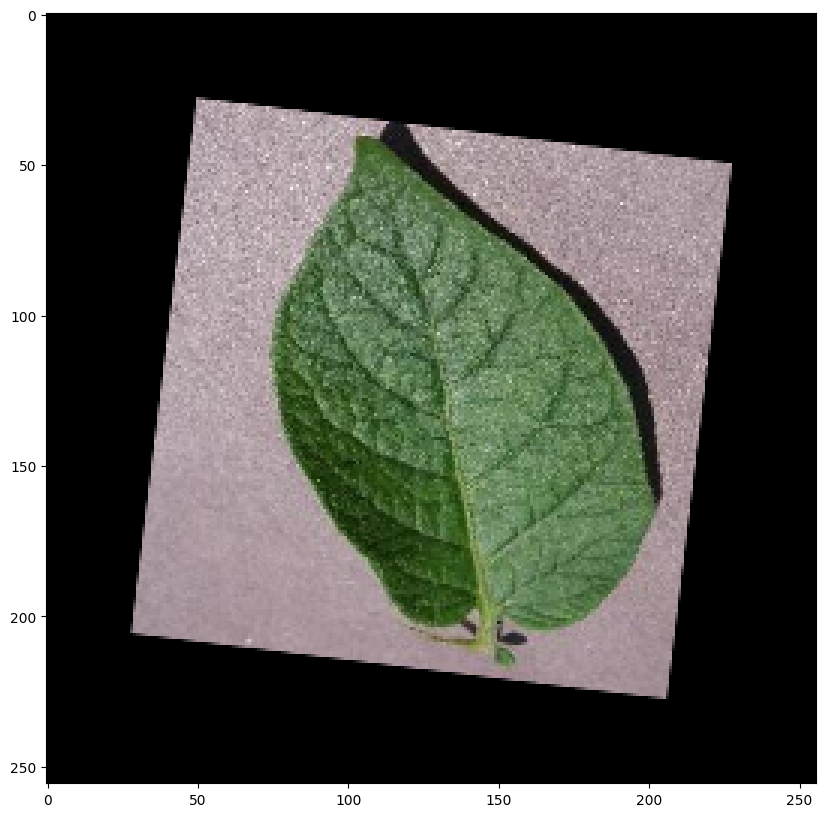

In [64]:
fig, axs = plt.subplots(1,1,figsize=(10,10))
axs.imshow(augmented_healthy_image_data[-1][0])

plt.show()

Now that we have performed data augmenatation, let us prepare our data into the train-test split.

In [ ]:
early_blight_data = [(cv2.imread(img), CLASS_TO_ID["Early-Blight"]) for img in file_paths["Early-Blight"]]
late_blight_data = [(cv2.imread(img), CLASS_TO_ID["Late-Blight"]) for img in file_paths["Late-Blight"]]
